In [8]:
# Einfluss von Wetterbedingungen auf Flugverspätungen
## Flughafen Wien (Vienna International Airport) Gruppe 9

In [9]:
# 1. Imports & Setup


# Bibliotheken für Datenanalyse
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliothek für MongoDB-Verbindung
from pymongo import MongoClient

# Für konsistente und gut lesbare Visualisierungen
sns.set(style="whitegrid")

In [10]:
# 2. MongoDB-Verbindung herstellen


# Verbindung zur lokalen MongoDB
client = MongoClient('mongodb://localhost:27017/')
db = client['fluege_wetter']

# Collections auswählen
flights_collection = db['flights']
weather_collection = db['weather']

# Vorhandene Collections prüfen
print("Collections in der Datenbank:", db.list_collection_names())

Collections in der Datenbank: ['weather', 'flights']


In [11]:
# 3. Daten laden


# Flugdaten laden
flights = pd.read_csv('all_pre_departure_delays_2025.csv')
flights['scheduled_departure'] = pd.to_datetime(flights['FLT_DATE'])

# Filter: nur Flüge am Flughafen Wien (LOWW)
flights = flights[flights['APT_ICAO'] == 'LOWW']

# Wetterdaten laden
weather = pd.read_csv('weather.csv', decimal=',')
weather['datetime'] = pd.to_datetime(weather['date'])

# Erste 5 Zeilen prüfen
print("Flugdaten:")
print(flights.head())

print("\nWetterdaten:")
print(weather.head())

Flugdaten:
      YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO APT_NAME STATE_NAME  \
7     2025          1       JAN  2025-01-01     LOWW   Vienna    Austria   
293   2025          1       JAN  2025-01-02     LOWW   Vienna    Austria   
598   2025          1       JAN  2025-01-03     LOWW   Vienna    Austria   
908   2025          1       JAN  2025-01-04     LOWW   Vienna    Austria   
1203  2025          1       JAN  2025-01-05     LOWW   Vienna    Austria   

      FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2 scheduled_departure  
7           253          253.0         3015.0          2025-01-01  
293         310          310.0         5975.0          2025-01-02  
598         335          335.0         5809.0          2025-01-03  
908         267          267.0         5214.0          2025-01-04  
1203        302          302.0         8692.0          2025-01-05  

Wetterdaten:
                  date  tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt  \
0  2025-01-01 00:00:00  -3.4  -4.0  

In [12]:
# 4. Daten in MongoDB importieren


# Alte Daten löschen (optional, falls schon Daten vorhanden)
flights_collection.delete_many({})
weather_collection.delete_many({})

# Flugdaten
flights_collection.insert_many(flights.to_dict('records'))

# Wetterdaten
weather_collection.insert_many(weather.to_dict('records'))

print("Daten erfolgreich in MongoDB importiert!")

Daten erfolgreich in MongoDB importiert!


In [13]:
#5. Daten aus MongoDB abrufen


# Flugdaten
df_flights = pd.DataFrame(list(flights_collection.find()))

# Wetterdaten
df_weather = pd.DataFrame(list(weather_collection.find()))

# Erste 5 Zeilen prüfen
print("Flugdaten:")
print(df_flights.head())

print("\nWetterdaten:")
print(df_weather.head())

Flugdaten:
                        _id  YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO  \
0  69d3ed7345fe123d13b55b23  2025          1       JAN  2025-01-01     LOWW   
1  69d3ed7345fe123d13b55b24  2025          1       JAN  2025-01-02     LOWW   
2  69d3ed7345fe123d13b55b25  2025          1       JAN  2025-01-03     LOWW   
3  69d3ed7345fe123d13b55b26  2025          1       JAN  2025-01-04     LOWW   
4  69d3ed7345fe123d13b55b27  2025          1       JAN  2025-01-05     LOWW   

  APT_NAME STATE_NAME  FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2  \
0   Vienna    Austria        253          253.0         3015.0   
1   Vienna    Austria        310          310.0         5975.0   
2   Vienna    Austria        335          335.0         5809.0   
3   Vienna    Austria        267          267.0         5214.0   
4   Vienna    Austria        302          302.0         8692.0   

  scheduled_departure  
0          2025-01-01  
1          2025-01-02  
2          2025-01-03  
3          2025-01-04

In [14]:
# 6. Flugdaten & Wetterdaten zusammenführen


# Merge der Flugdaten mit Wetterdaten anhand des Abflugdatums
df_merged = pd.merge(
    df_flights,
    df_weather,
    left_on='scheduled_departure', # Flugdaten
    right_on='datetime', # Wetterdaten
    how='left' # Left Join: alle Flüge behalten, Wetterdaten ergänzen
)

# Ergebnis prüfen
print("Zusammengeführte Daten:")
print(df_merged.head())

Zusammengeführte Daten:
                      _id_x  YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO  \
0  69d3ed7345fe123d13b55b23  2025          1       JAN  2025-01-01     LOWW   
1  69d3ed7345fe123d13b55b24  2025          1       JAN  2025-01-02     LOWW   
2  69d3ed7345fe123d13b55b25  2025          1       JAN  2025-01-03     LOWW   
3  69d3ed7345fe123d13b55b26  2025          1       JAN  2025-01-04     LOWW   
4  69d3ed7345fe123d13b55b27  2025          1       JAN  2025-01-05     LOWW   

  APT_NAME STATE_NAME  FLT_DEP_1  FLT_DEP_IFR_2  ...  tmin tmax prcp snow  \
0   Vienna    Austria        253          253.0  ...  -4.0 -2.8  0.0  NaN   
1   Vienna    Austria        310          310.0  ...  -3.2 -0.4  NaN  NaN   
2   Vienna    Austria        335          335.0  ...   0.8  4.4  NaN  NaN   
3   Vienna    Austria        267          267.0  ...  -2.2  3.1  0.0  NaN   
4   Vienna    Austria        302          302.0  ...  -3.7  0.3  NaN  NaN   

   wdir  wspd  wpgt    pres   tsun   d

Durchschnittliche Verspätung nach Temperaturbereich:
temp_range
(-10, 0]    278.269231
(0, 10]     314.629630
(10, 20]    372.717241
(20, 30]    389.677966
(30, 40]           NaN
Name: FLT_DEP_1, dtype: float64


C:\Users\noahf\AppData\Local\Temp\ipykernel_26064\1285677342.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_delay = df_merged.groupby('temp_range')['FLT_DEP_1'].mean()


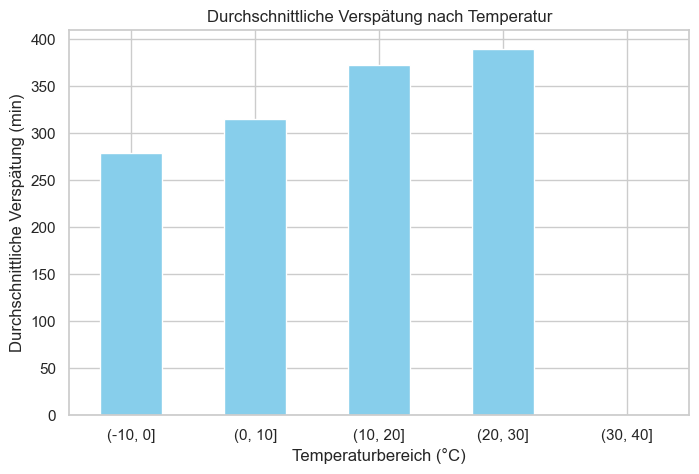

In [15]:
# 7. Analyse: Durchschnittliche Verspätung nach Temperatur


# Temperaturbereiche definieren (°C)
temp_bins = [-10, 0, 10, 20, 30, 40]
df_merged['temp_range'] = pd.cut(df_merged['tavg'], bins=temp_bins)

# Durchschnittliche Verspätung pro Temperaturbereich berechnen
avg_delay = df_merged.groupby('temp_range')['FLT_DEP_1'].mean()

# Ergebnisse ausgeben
print("Durchschnittliche Verspätung nach Temperaturbereich:")
print(avg_delay)

# Visualisierung Balkendiagramm
avg_delay.plot(kind='bar', figsize=(8,5), color='skyblue')
plt.xlabel("Temperaturbereich (°C)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Temperatur")
plt.xticks(rotation=0)  # X-Achsen-Beschriftung horizontal
plt.show()

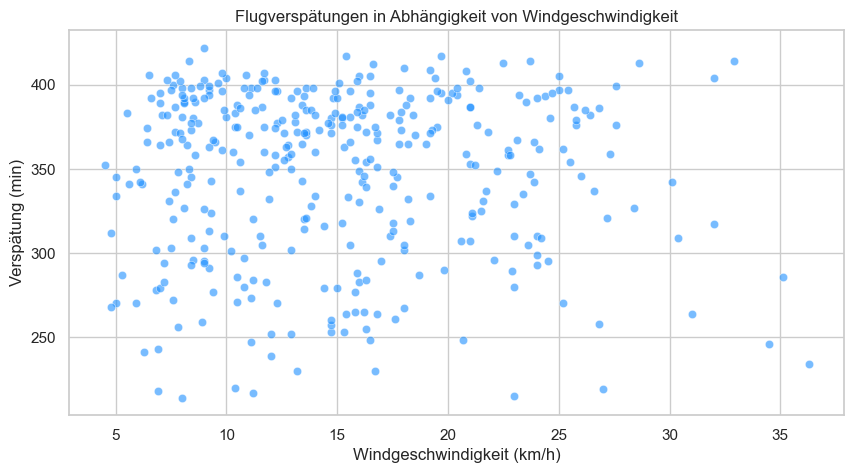

In [16]:
# 8. Analyse: Verspätung vs. Windgeschwindigkeit


# Scatterplot: Verspätung in Abhängigkeit von Windgeschwindigkeit
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='wspd',
    y='FLT_DEP_1',
    data=df_merged,
    color='dodgerblue',
    alpha=0.6
)

# Achsenbeschriftungen und Titel
plt.xlabel("Windgeschwindigkeit (km/h)")
plt.ylabel("Verspätung (min)")
plt.title("Flugverspätungen in Abhängigkeit von Windgeschwindigkeit")
plt.show()

Aggregierte Daten nach Temperatur:
    tavg   avg_delay
0   -4.0  282.200000
1   -3.0  259.666667
2   -2.0  274.500000
3   -1.0  285.833333
4    0.0  289.421053
5    1.0  287.076923
6    2.0  309.300000
7    3.0  314.166667
8    4.0  289.428571
9    5.0  331.200000
10   6.0  295.666667
11   7.0  345.571429
12   8.0  326.461538
13   9.0  353.875000
14  10.0  350.687500
15  11.0  350.333333
16  12.0  368.750000
17  13.0  373.500000
18  14.0  367.125000
19  15.0  369.750000
20  16.0  377.000000
21  17.0  385.875000
22  18.0  383.631579
23  19.0  393.000000
24  20.0  383.071429
25  21.0  391.714286
26  22.0  391.777778
27  23.0  384.142857
28  24.0  395.125000
29  25.0  391.000000
30  26.0  387.333333
31  27.0  400.000000


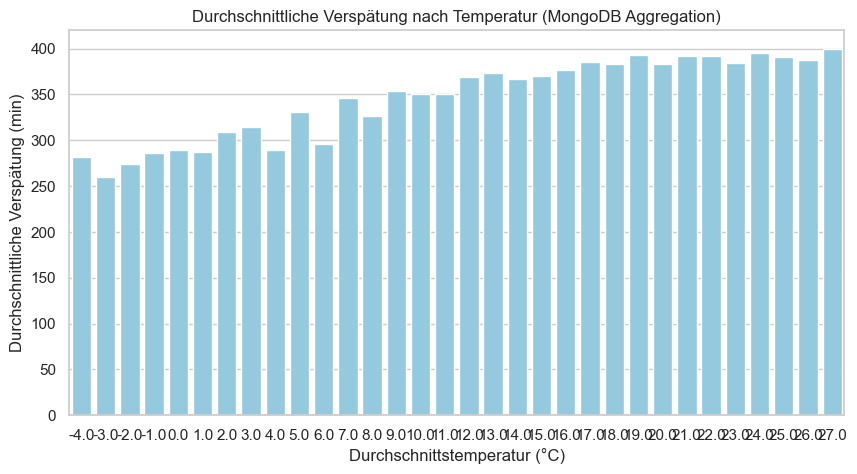

In [17]:
# 9. Aggregation in MongoDB: Durchschnittliche Verspätung nach Temperatur


# Pipeline definieren für Aggregation in MongoDB
pipeline_temp = [
    {
        "$lookup": {  # Verknüpfung mit Wetter-Collection
            "from": "weather",
            "localField": "scheduled_departure",
            "foreignField": "datetime",
            "as": "weather_info"
        }
    },
    {"$unwind": "$weather_info"},  # Array auflösen, damit jedes Wetterobjekt eine Zeile wird
    {
        "$group": {  # Gruppieren nach abgerundeter Durchschnittstemperatur
            "_id": {"tavg": {"$floor": "$weather_info.tavg"}},
            "avg_delay": {"$avg": "$FLT_DEP_1"}  # Durchschnittliche Verspätung berechnen
        }
    },
    {"$sort": {"_id.tavg": 1}}  # Aufsteigend nach Temperatur sortieren
]

# Aggregation ausführen
result = list(flights_collection.aggregate(pipeline_temp))

# In DataFrame umwandeln
df_agg_temp = pd.DataFrame(result)
df_agg_temp.rename(columns={"_id": "tavg"}, inplace=True)
df_agg_temp["tavg"] = df_agg_temp["tavg"].apply(lambda x: x["tavg"])  # Wert extrahieren

# Ergebnis prüfen
print("Aggregierte Daten nach Temperatur:")
print(df_agg_temp)

# Visualisierung: Balkendiagramm
plt.figure(figsize=(10,5))
sns.barplot(x="tavg", y="avg_delay", data=df_agg_temp, color='skyblue')
plt.xlabel("Durchschnittstemperatur (°C)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Temperatur (MongoDB Aggregation)")
plt.show()

Aggregierte Daten nach Niederschlag:
   prcp   avg_delay
0   NaN  298.068182
1   0.0  348.960474
2   1.0  369.461538
3   2.0  364.111111
4   3.0  362.400000


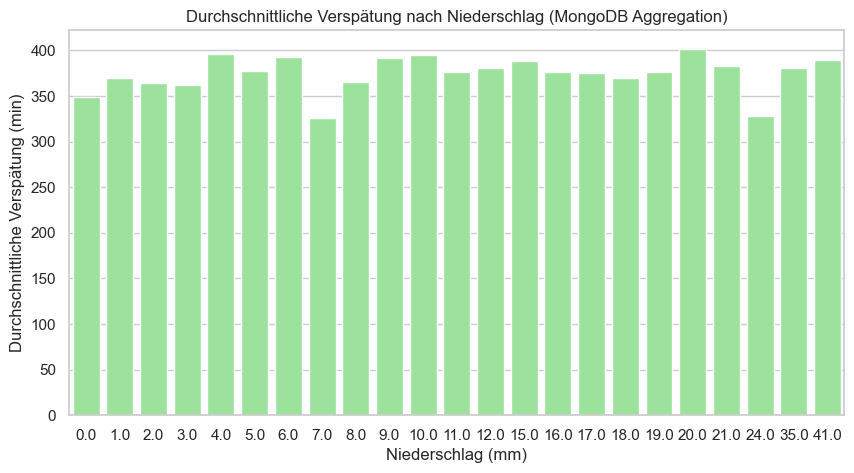

In [18]:
# 10. Aggregation in MongoDB: Durchschnittliche Verspätung nach Niederschlag


# Pipeline definieren für Aggregation in MongoDB (Niederschlag)
pipeline_prcp = [
    {
        "$lookup": {  # Verknüpfung mit Wetter-Collection
            "from": "weather",
            "localField": "scheduled_departure",
            "foreignField": "datetime",
            "as": "weather_info"
        }
    },
    {"$unwind": "$weather_info"},  # Array auflösen, jedes Wetterobjekt wird zur Zeile
    {
        "$group": {  # Gruppieren nach abgerundetem Niederschlag
            "_id": {"prcp": {"$floor": "$weather_info.prcp"}},
            "avg_delay": {"$avg": "$FLT_DEP_1"}  # Durchschnittliche Verspätung
        }
    },
    {"$sort": {"_id.prcp": 1}}  # Aufsteigend nach Niederschlag sortieren
]

# Aggregation ausführen
result_prcp = list(flights_collection.aggregate(pipeline_prcp))

# In DataFrame umwandeln
df_prcp = pd.DataFrame(result_prcp)
df_prcp.rename(columns={"_id": "prcp"}, inplace=True)
df_prcp["prcp"] = df_prcp["prcp"].apply(lambda x: x["prcp"])  # Wert extrahieren

# Ergebnis prüfen
print("Aggregierte Daten nach Niederschlag:")
print(df_prcp.head())

# Visualisierung: Balkendiagramm
plt.figure(figsize=(10,5))
sns.barplot(x="prcp", y="avg_delay", data=df_prcp, color='lightgreen')
plt.xlabel("Niederschlag (mm)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Niederschlag (MongoDB Aggregation)")
plt.show()

In [24]:
# 11. Flugdaten + Wetterdaten mergen

# 1. Beide Zeitspalten in echtes Datumsformat umwandeln
flights['FLT_DATE'] = pd.to_datetime(flights['FLT_DATE'])
weather['datetime'] = pd.to_datetime(weather['datetime'])

# 2. Merge
df_merged_copy = pd.merge(
    flights,
    weather.copy(),
    left_on='FLT_DATE',
    right_on='datetime',
    how='left'
)

# 3. Schnee NaN → 0
df_merged_copy['snow'] = df_merged_copy['snow'].fillna(0)

Durchschnittliche Verspätung nach Windgeschwindigkeit (erste 10 Werte):
   wspd_floor   FLT_DEP_1
0           4  310.666667
1           5  322.500000
2           6  318.454545
3           7  351.583333
4           8  358.074074
5           9  355.375000
6          10  344.555556
7          11  342.761905
8          12  345.714286
9          13  360.450000


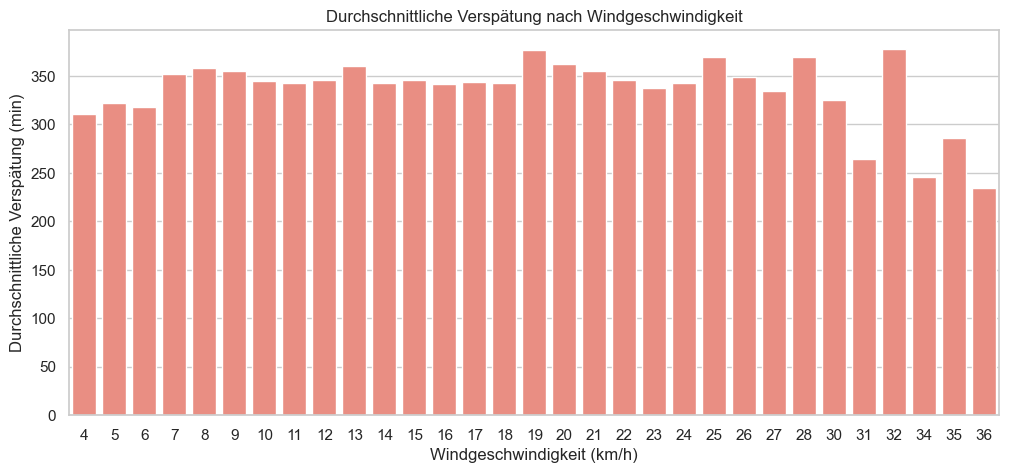

In [25]:
# 12. Analyse: Durchschnittliche Verspätung nach Windgeschwindigkeit


# 1. NaN in 'wspd' auf 0 setzen (falls vorhanden)
df_weather_copy = df_weather.copy()
df_weather_copy['wspd'] = df_weather_copy['wspd'].fillna(0)

# 2. Merge mit Flugdaten
df_merged_copy = pd.merge(
    df_flights,
    df_weather_copy,
    left_on='scheduled_departure',
    right_on='datetime',
    how='left'
)

# 3. Windgeschwindigkeit auf ganze Zahlen runden
df_merged_copy['wspd_floor'] = df_merged_copy['wspd'].apply(lambda x: int(x))

# 4. Gruppieren: Durchschnittliche Verspätung je Windgeschwindigkeit
df_wind_plot = df_merged_copy.groupby('wspd_floor')['FLT_DEP_1'].mean().reset_index()

# Ergebnisse prüfen
print("Durchschnittliche Verspätung nach Windgeschwindigkeit (erste 10 Werte):")
print(df_wind_plot.head(10))

# 5. Visualisierung: Balkendiagramm
plt.figure(figsize=(12,5))
sns.barplot(x='wspd_floor', y='FLT_DEP_1', data=df_wind_plot, color='salmon')
plt.xlabel("Windgeschwindigkeit (km/h)")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Windgeschwindigkeit")
plt.show()

Durchschnittliche Verspätung nach Monat:
    month   FLT_DEP_1
0       1  269.419355
1       2  284.214286
2       3  305.290323
3       4  359.433333
4       5  371.806452
5       6  387.766667
6       7  389.193548
7       8  389.806452
8       9  394.833333
9      10  378.258065
10     11  319.366667
11     12  313.806452


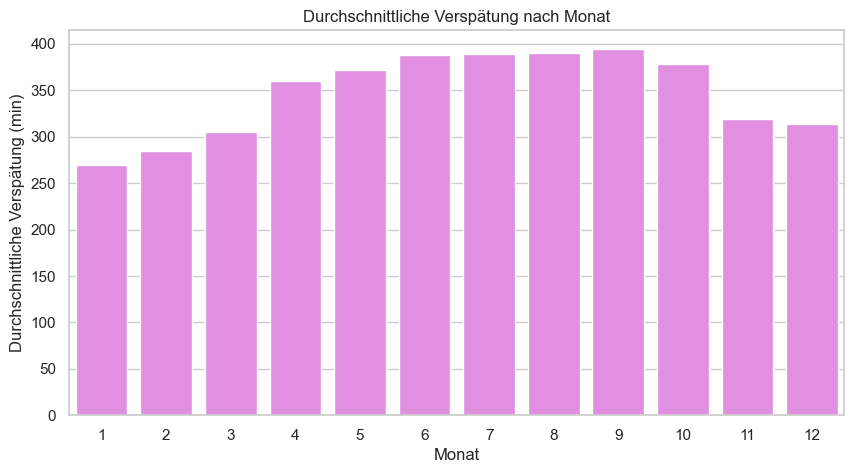

In [26]:
# 13. Analyse: Durchschnittliche Verspätung nach Monat


# 1. Monat aus dem Abflugdatum extrahieren
df_merged_copy = df_flights.copy()
df_merged_copy['month'] = df_merged_copy['scheduled_departure'].dt.month

# 2. Gruppieren: Durchschnittliche Verspätung je Monat
df_month_plot = df_merged_copy.groupby('month')['FLT_DEP_1'].mean().reset_index()

# Ergebnisse prüfen
print("Durchschnittliche Verspätung nach Monat:")
print(df_month_plot)

# 3. Visualisierung: Balkendiagramm
plt.figure(figsize=(10,5))
sns.barplot(x='month', y='FLT_DEP_1', data=df_month_plot, color='violet')
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Verspätung (min)")
plt.title("Durchschnittliche Verspätung nach Monat")
plt.show()